# Dashboard Vision Analysis with a Dual-Engine VLM (Gemini Vision + LLaVA)

This notebook implements the **VLM integration** future-work item of the Multimodal RCA
Engine paper: direct pixel-level anomaly analysis of the generated Grafana-style
**Dashboard PNG** images, run through two independent Vision-Language Model (VLM) engines,
mirroring the dual-engine pattern already used for the text LLM layer (local vs. cloud):

- **Cloud engine** — Google **Gemini Vision** (`gemini-3.5-flash`), called through the API.
- **Local engine** — **LLaVA** (`llava:7b`), served locally through Ollama, no external calls.

Both engines look *only* at the dashboard image (no metric or log features) and return a
structured JSON verdict. We then score that visual-only verdict against the dataset's
ground truth to see how much anomaly signal is recoverable from the image alone, and we
benchmark the two engines the same way Section 7 of the paper benchmarks the text LLMs.

| Step | Topic |
|------|------|
| 1 | Environment setup |
| 2 | Connect to both VLM engines |
| 3 | Select an evaluation sample from the dataset |
| 4 | Preview the selected dashboards |
| 5 | Run the cloud engine (Gemini Vision) |
| 6 | Run the local engine (Ollama LLaVA) |
| 7 | Score against ground truth |
| 8 | Benchmark summary table |
| 9 | Visualization |
| 10 | Detailed example: a critical anomaly |
| 11 | Save results |
| 12 | Summary and next steps |


## 1 — Environment Setup

### Required packages
```
pip install google-generativeai python-dotenv pillow requests
```

### Gemini API key
Add it to `.env` in the project root:
```
GEMINI_API_KEY=your_api_key_here
```

### Local LLaVA model (optional, for the local engine)
```
ollama pull llava:7b
```
If Ollama is not running or `llava:7b` is not installed, this notebook automatically skips
the local-engine section and reports results for the cloud engine only.


In [1]:
import sys, os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml
import requests
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
sys.path.insert(0, r"d:\multimodal-rca-engine")

from dotenv import load_dotenv
load_dotenv(Path(r"d:\multimodal-rca-engine\.env"))

from models.vlm_engine import VLMEngine

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROJECT_DIR = Path(r"d:\multimodal-rca-engine")
DATASET_DIR = PROJECT_DIR / "data" / "multimodal_dataset"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")
print(f"Dataset directory: {DATASET_DIR}")


Libraries loaded.
Dataset directory: d:\multimodal-rca-engine\data\multimodal_dataset


## 2 — Connect to Both VLM Engines

We check that:
1. The Gemini API key is configured (cloud engine).
2. An Ollama server is reachable and `llava:7b` is pulled (local engine).

Engine instantiation itself is free (no API call yet) — the actual connectivity is proven
in Section 5/6 when we run the first real analysis.


In [2]:
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY not found.\n"
        "Add it to d:/multimodal-rca-engine/.env:\n"
        "  GEMINI_API_KEY=your_key_here"
    )

gemini_engine = VLMEngine(backend="gemini")
print(f"Cloud engine ready  : Gemini Vision ({gemini_engine.client.model_name})")

# Check whether a local vision-capable Ollama model is available
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")
OLLAMA_VISION_MODEL = os.environ.get("DEFAULT_OLLAMA_VISION_MODEL", "llava:7b")
OLLAMA_AVAILABLE = False
try:
    tags = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5).json()
    installed = [m["name"] for m in tags.get("models", [])]
    OLLAMA_AVAILABLE = OLLAMA_VISION_MODEL in installed
    print(f"Local Ollama server : reachable, {len(installed)} model(s) installed")
    print(f"Local engine ready  : {'yes — ' + OLLAMA_VISION_MODEL if OLLAMA_AVAILABLE else 'NO — ' + OLLAMA_VISION_MODEL + ' not pulled'}")
except requests.exceptions.RequestException:
    print("Local Ollama server : NOT reachable — local-engine sections will be skipped")

ollama_engine = VLMEngine(backend="ollama") if OLLAMA_AVAILABLE else None


 Initializing VLMEngine (Backend: GEMINI)
Cloud engine ready  : Gemini Vision (gemini-3.5-flash)


Local Ollama server : reachable, 7 model(s) installed
Local engine ready  : yes — llava:7b
 Initializing VLMEngine (Backend: OLLAMA)


## 3 — Select an Evaluation Sample from the Dataset

Calling a hosted VLM API is slow and rate-limited (the Gemini free tier caps requests per
minute) and the local CPU-bound LLaVA model takes 1–2 minutes per image, so we cannot run
the whole 10,000-sample dataset here. Instead we draw a small, **deliberately diverse**
sample: a few normal dashboards from different layers, plus one anomalous dashboard for
each of several distinct visual patterns (`spike`, `gradual_rise`, `sustained_high`,
`oscillation`, `step_increase`) so that both engines are exercised on every kind of visual
signature they might encounter, not just repeats of the same pattern.


In [3]:
# Load the scenario catalog to know each scenario's visual anomaly_type
with open(PROJECT_DIR / "configs" / "anomaly_scenarios.yaml", "r", encoding="utf-8") as f:
    catalog_cfg = yaml.safe_load(f)

scenario_catalog = {}
for layer_key, layer_data in catalog_cfg["layers"].items():
    for sc in layer_data["scenarios"]:
        scenario_catalog[sc["id"]] = sc

metadata = pd.read_csv(DATASET_DIR / "metadata.csv")
print(f"Metadata loaded: {len(metadata):,} samples")

rng = np.random.RandomState(42)

# --- 3 normal samples from 3 different layers ---
normal_pool = metadata[metadata["is_anomaly"] == 0]
normal_layers = rng.choice(normal_pool["layer"].unique(), size=3, replace=False)
normal_picks = pd.concat(
    [normal_pool[normal_pool["layer"] == lyr].sample(1, random_state=42) for lyr in normal_layers]
)

# --- 1 anomalous sample per distinct visual anomaly_type ---
anomaly_pool = metadata[metadata["is_anomaly"] == 1].copy()
anomaly_pool["anomaly_type"] = anomaly_pool["scenario_id"].map(
    lambda sid: scenario_catalog.get(sid, {}).get("anomaly_type", "unknown")
)
anomaly_picks = (
    anomaly_pool.groupby("anomaly_type", group_keys=False)
    .apply(lambda g: g.sample(1, random_state=42))
    .head(5)
)

eval_samples = pd.concat([normal_picks, anomaly_picks]).reset_index(drop=True)
eval_samples["anomaly_type"] = eval_samples["scenario_id"].map(
    lambda sid: scenario_catalog.get(sid, {}).get("anomaly_type", "-") if pd.notna(sid) else "-"
)

print(f"\nSelected {len(eval_samples)} samples for evaluation:")
eval_samples[["sample_id", "layer_name", "is_anomaly", "scenario_name", "anomaly_type", "severity"]]


Metadata loaded: 10,000 samples

Selected 8 samples for evaluation:


,sample_id,layer_name,is_anomaly,scenario_name,anomaly_type,severity
0,sample_002578,Application Layer,0,NaN,-,NaN
1,sample_000303,CDN,0,NaN,-,NaN
2,sample_004394,Linux VM,0,NaN,-,NaN
3,sample_009464,Linux VM,1,Memory Exhaustion,gradual_rise,critical
4,sample_006605,Kubernetes Ingress,1,Unbalanced Traffic Distribution,oscillation,medium
5,sample_008809,Network,1,Packet Loss Increase,spike,high
6,sample_009783,Linux Host (Physical Machine),1,Disk Error Count Increase,step_increase,critical
7,sample_009277,Linux VM,1,CPU Usage Surge,sustained_high,high


## 4 — Preview the Selected Dashboards

A quick visual sanity check before spending API calls: these are the actual Grafana-style
PNGs the VLMs will see.


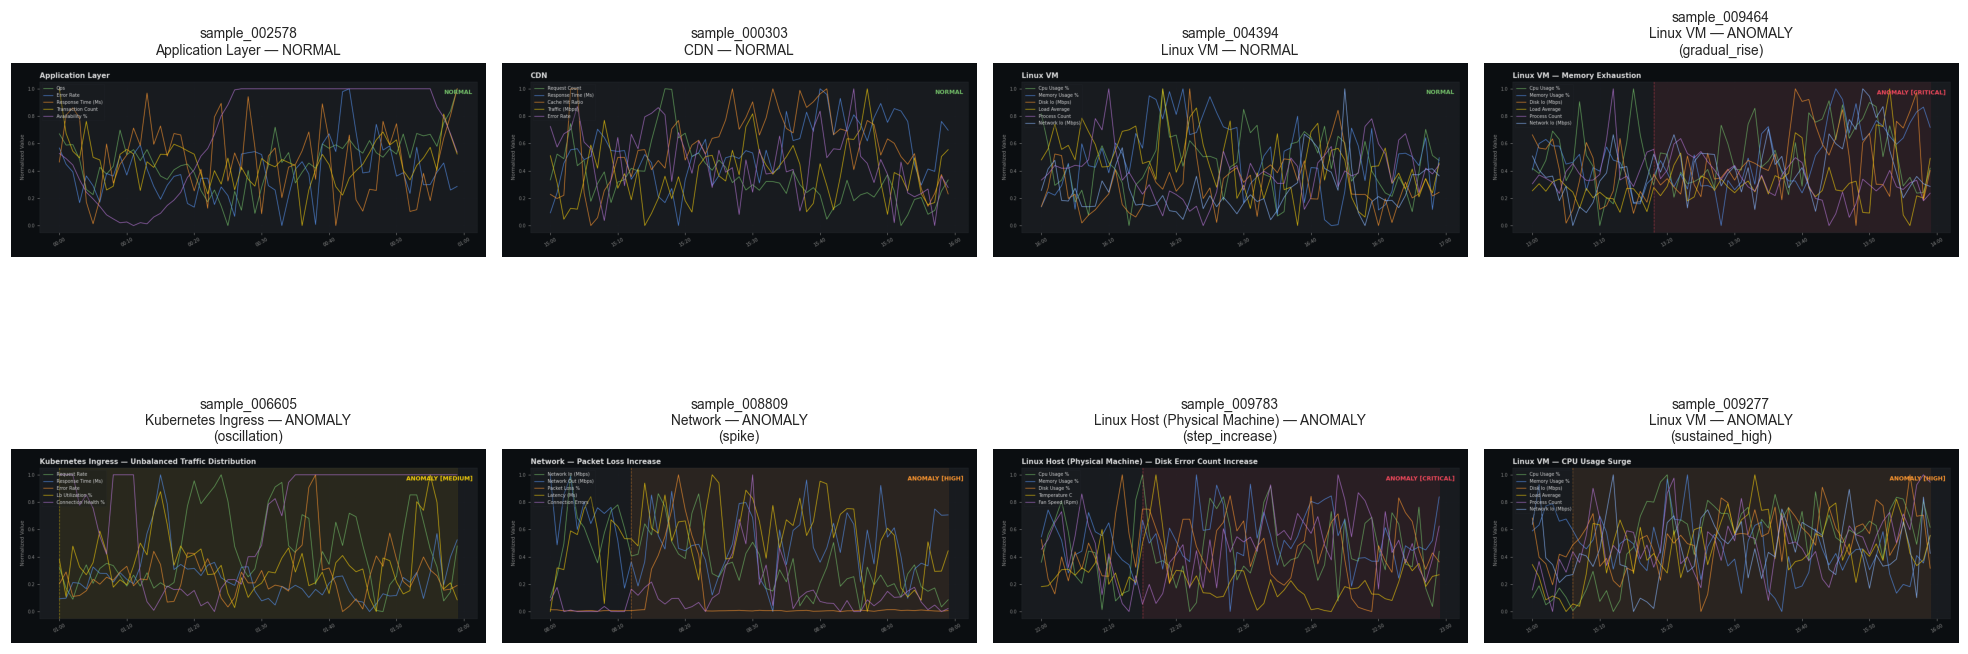

In [4]:
n = len(eval_samples)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.atleast_2d(axes)

for i, row in eval_samples.iterrows():
    ax = axes[i // ncols][i % ncols]
    img_path = DATASET_DIR / row["dashboard_path"]
    ax.imshow(mpimg.imread(img_path))
    status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
    label = f"{row['sample_id']}\n{row['layer_name']} — {status}"
    if row["is_anomaly"]:
        label += f"\n({row['anomaly_type']})"
    ax.set_title(label, fontsize=9)
    ax.axis("off")

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

plt.tight_layout()
plt.show()


## 5 — Run the Cloud Engine (Gemini Vision)

Each call sends the dashboard PNG plus a fixed system prompt (see
`models/vlm_engine.py::VLM_SYSTEM_PROMPT`) asking Gemini to decide `NORMAL` vs `ANOMALY`,
estimate its confidence, name the visual pattern it sees, and justify itself in one or two
sentences — purely from the pixels. `VLMEngine` paces requests and retries automatically on
HTTP 429 (rate limit) so this cell can simply be run once.


In [5]:
gemini_results = []
print(f"Running Gemini Vision on {len(eval_samples)} dashboards...\n")

for i, row in eval_samples.iterrows():
    img_path = DATASET_DIR / row["dashboard_path"]
    t0 = time.time()
    res = gemini_engine.analyze_dashboard(img_path)
    gt_status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
    ok = "error" not in res
    match = (res.get("visual_status") == gt_status) if ok else False

    gemini_results.append({
        "sample_id": row["sample_id"], "layer": row["layer_name"],
        "gt_status": gt_status, "scenario_name": row.get("scenario_name"),
        "anomaly_type": row.get("anomaly_type"),
        "visual_status": res.get("visual_status"),
        "visual_confidence": res.get("visual_confidence"),
        "visual_pattern": res.get("visual_pattern"),
        "visual_explanation": res.get("visual_explanation"),
        "latency_seconds": res.get("latency_seconds"),
        "parsed_ok": ok, "correct": match, "backend": "gemini",
    })
    flag = "OK   " if not ok else ("MATCH" if match else "MISS ")
    print(f"[{i+1}/{len(eval_samples)}] {row['sample_id']:<16} gt={gt_status:<7} "
          f"pred={res.get('visual_status','ERROR'):<7} {flag} "
          f"({res.get('latency_seconds','?')}s)")

gemini_df = pd.DataFrame(gemini_results)
gemini_df


Running Gemini Vision on 8 dashboards...



[1/8] sample_002578    gt=NORMAL  pred=NORMAL  MATCH (9.8s)


[2/8] sample_000303    gt=NORMAL  pred=NORMAL  MATCH (9.773s)


[3/8] sample_004394    gt=NORMAL  pred=NORMAL  MATCH (12.934s)


[4/8] sample_009464    gt=ANOMALY pred=ANOMALY MATCH (38.126s)


[5/8] sample_006605    gt=ANOMALY pred=ANOMALY MATCH (10.71s)


[6/8] sample_008809    gt=ANOMALY pred=ANOMALY MATCH (9.625s)


[7/8] sample_009783    gt=ANOMALY pred=ANOMALY MATCH (9.283s)


[8/8] sample_009277    gt=ANOMALY pred=ANOMALY MATCH (10.575s)


,sample_id,layer,gt_status,scenario_name,anomaly_type,visual_status,visual_confidence,visual_pattern,visual_explanation,latency_seconds,parsed_ok,correct,backend
0,sample_002578,Application Layer,NORMAL,NaN,-,NORMAL,0.95,none,The dashboard displays normal fluctuating metr...,9.800,True,True,gemini
1,sample_000303,CDN,NORMAL,NaN,-,NORMAL,0.98,none,The dashboard displays a green 'NORMAL' status...,9.773,True,True,gemini
2,sample_004394,Linux VM,NORMAL,NaN,-,NORMAL,0.98,none,The metrics fluctuate within normal ranges wit...,12.934,True,True,gemini
3,sample_009464,Linux VM,ANOMALY,Memory Exhaustion,gradual_rise,ANOMALY,1.00,gradual_rise,The dashboard displays a red dashed vertical l...,38.126,True,True,gemini
4,sample_006605,Kubernetes Ingress,ANOMALY,Unbalanced Traffic Distribution,oscillation,ANOMALY,0.95,none,The dashboard displays an 'ANOMALY [MEDIUM]' b...,10.710,True,True,gemini
5,sample_008809,Network,ANOMALY,Packet Loss Increase,spike,ANOMALY,1.00,spike,"An anomaly is detected starting around 08:12, ...",9.625,True,True,gemini
6,sample_009783,Linux Host (Physical Machine),ANOMALY,Disk Error Count Increase,step_increase,ANOMALY,1.00,none,The dashboard explicitly marks an anomaly star...,9.283,True,True,gemini
7,sample_009277,Linux VM,ANOMALY,CPU Usage Surge,sustained_high,ANOMALY,1.00,gradual_rise,An anomaly is flagged starting around 15:06 wi...,10.575,True,True,gemini


## 6 — Run the Local Engine (Ollama LLaVA)

`llava:7b` runs entirely on this machine (no data leaves the network — the same
privacy argument the paper makes for Llama 3.2 on the text side) but is much slower on
CPU-only hardware, so we evaluate it on a **smaller, stratified subset** of the sample
(2 normal + 2 anomalous dashboards, not just the first N rows — `eval_samples` lists all
3 normals before any anomaly, so a naive `.iloc[:3]` slice would silently test LLaVA on
normals only) to keep the notebook's runtime reasonable while still enabling a fair
head-to-head comparison on both classes.


In [6]:
RUN_OLLAMA = OLLAMA_AVAILABLE
OLLAMA_N_NORMAL, OLLAMA_N_ANOMALY = 2, 2  # keep small: local CPU inference is ~1-2 min/image

ollama_results = []
if RUN_OLLAMA:
    # Stratified subset: eval_samples lists all normals before all anomalies, so a plain
    # .iloc[:N] slice would test only one class. Sample explicitly from both instead.
    subset = pd.concat([
        eval_samples[eval_samples["is_anomaly"] == 0].head(OLLAMA_N_NORMAL),
        eval_samples[eval_samples["is_anomaly"] == 1].head(OLLAMA_N_ANOMALY),
    ]).reset_index(drop=True)
    print(f"Running Ollama LLaVA on {len(subset)} dashboards "
          f"({OLLAMA_N_NORMAL} normal + {OLLAMA_N_ANOMALY} anomaly, this can take a few minutes)...\n")
    for i, row in subset.iterrows():
        img_path = DATASET_DIR / row["dashboard_path"]
        res = ollama_engine.analyze_dashboard(img_path)
        gt_status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
        ok = "error" not in res
        match = (res.get("visual_status") == gt_status) if ok else False

        ollama_results.append({
            "sample_id": row["sample_id"], "layer": row["layer_name"],
            "gt_status": gt_status, "scenario_name": row.get("scenario_name"),
            "anomaly_type": row.get("anomaly_type"),
            "visual_status": res.get("visual_status"),
            "visual_confidence": res.get("visual_confidence"),
            "visual_pattern": res.get("visual_pattern"),
            "visual_explanation": res.get("visual_explanation"),
            "latency_seconds": res.get("latency_seconds"),
            "parsed_ok": ok, "correct": match, "backend": "ollama",
        })
        flag = "OK   " if not ok else ("MATCH" if match else "MISS ")
        print(f"[{i+1}/{len(subset)}] {row['sample_id']:<16} gt={gt_status:<7} "
              f"pred={res.get('visual_status','ERROR'):<7} {flag} "
              f"({res.get('latency_seconds','?')}s)")
else:
    print("Ollama / llava:7b not available on this machine \u2014 skipping the local-engine run.")
    print("Install with:  ollama pull llava:7b")

ollama_df = pd.DataFrame(ollama_results)
ollama_df

Running Ollama LLaVA on 4 dashboards (2 normal + 2 anomaly, this can take a few minutes)...



[1/4] sample_002578    gt=NORMAL  pred=ANOMALY MISS  (125.436s)


[2/4] sample_000303    gt=NORMAL  pred=ANOMALY MISS  (69.517s)


[3/4] sample_009464    gt=ANOMALY pred=ANOMALY MATCH (68.18s)


[4/4] sample_006605    gt=ANOMALY pred=ANOMALY MATCH (68.263s)


,sample_id,layer,gt_status,scenario_name,anomaly_type,visual_status,visual_confidence,visual_pattern,visual_explanation,latency_seconds,parsed_ok,correct,backend
0,sample_002578,Application Layer,NORMAL,NaN,-,ANOMALY,0.8,oscillation,The dashboard shows a time-series panel with a...,125.436,True,False,ollama
1,sample_000303,CDN,NORMAL,NaN,-,ANOMALY,0.8,oscillation,The dashboard shows a time-series panel with m...,69.517,True,False,ollama
2,sample_009464,Linux VM,ANOMALY,Memory Exhaustion,gradual_rise,ANOMALY,0.9,oscillation,The dashboard shows a time-series panel for an...,68.180,True,True,ollama
3,sample_006605,Kubernetes Ingress,ANOMALY,Unbalanced Traffic Distribution,oscillation,ANOMALY,0.9,oscillation,The dashboard shows a time-series panel with a...,68.263,True,True,ollama


## 7 — Score Against Ground Truth

We merge both engines' results into a single table and flag correctness per sample.


In [7]:
all_results = pd.concat([gemini_df, ollama_df], ignore_index=True) if len(ollama_df) else gemini_df.copy()
all_results


,sample_id,layer,gt_status,scenario_name,anomaly_type,visual_status,visual_confidence,visual_pattern,visual_explanation,latency_seconds,parsed_ok,correct,backend
0,sample_002578,Application Layer,NORMAL,NaN,-,NORMAL,0.95,none,The dashboard displays normal fluctuating metr...,9.800,True,True,gemini
1,sample_000303,CDN,NORMAL,NaN,-,NORMAL,0.98,none,The dashboard displays a green 'NORMAL' status...,9.773,True,True,gemini
2,sample_004394,Linux VM,NORMAL,NaN,-,NORMAL,0.98,none,The metrics fluctuate within normal ranges wit...,12.934,True,True,gemini
3,sample_009464,Linux VM,ANOMALY,Memory Exhaustion,gradual_rise,ANOMALY,1.00,gradual_rise,The dashboard displays a red dashed vertical l...,38.126,True,True,gemini
4,sample_006605,Kubernetes Ingress,ANOMALY,Unbalanced Traffic Distribution,oscillation,ANOMALY,0.95,none,The dashboard displays an 'ANOMALY [MEDIUM]' b...,10.710,True,True,gemini
5,sample_008809,Network,ANOMALY,Packet Loss Increase,spike,ANOMALY,1.00,spike,"An anomaly is detected starting around 08:12, ...",9.625,True,True,gemini
6,sample_009783,Linux Host (Physical Machine),ANOMALY,Disk Error Count Increase,step_increase,ANOMALY,1.00,none,The dashboard explicitly marks an anomaly star...,9.283,True,True,gemini
7,sample_009277,Linux VM,ANOMALY,CPU Usage Surge,sustained_high,ANOMALY,1.00,gradual_rise,An anomaly is flagged starting around 15:06 wi...,10.575,True,True,gemini
8,sample_002578,Application Layer,NORMAL,NaN,-,ANOMALY,0.80,oscillation,The dashboard shows a time-series panel with a...,125.436,True,False,ollama
9,sample_000303,CDN,NORMAL,NaN,-,ANOMALY,0.80,oscillation,The dashboard shows a time-series panel with m...,69.517,True,False,ollama


## 8 — Benchmark Summary Table

Same spirit as Table 9 in the paper (which benchmarks Llama 3.2 vs. Gemini 2.5 Flash on
text): per engine, we report **visual accuracy** against ground truth, the **JSON parse
success rate** (fraction of responses that yielded a valid structured verdict), **mean
response latency**, and **mean self-reported confidence**.


In [8]:
def summarize(df):
    n = len(df)
    if n == 0:
        return None
    return pd.Series({
        "n_samples": n,
        "accuracy": df["correct"].mean(),
        "json_parse_rate": df["parsed_ok"].mean(),
        "mean_latency_s": df["latency_seconds"].mean(),
        "mean_confidence": df.loc[df["parsed_ok"], "visual_confidence"].astype(float).mean(),
    })

summary = all_results.groupby("backend").apply(summarize)
summary = summary.round(3)
print("VLM Dual-Engine Benchmark Summary\n" + "=" * 40)
summary


VLM Dual-Engine Benchmark Summary


,n_samples,accuracy,json_parse_rate,mean_latency_s,mean_confidence
backend,,,,,
gemini,8.0,1.0,1.0,13.853,0.982
ollama,4.0,0.5,1.0,82.849,0.850


## 9 — Visualization

Accuracy, latency, and confidence side by side for the two engines, plus a per-sample
correct/incorrect view.


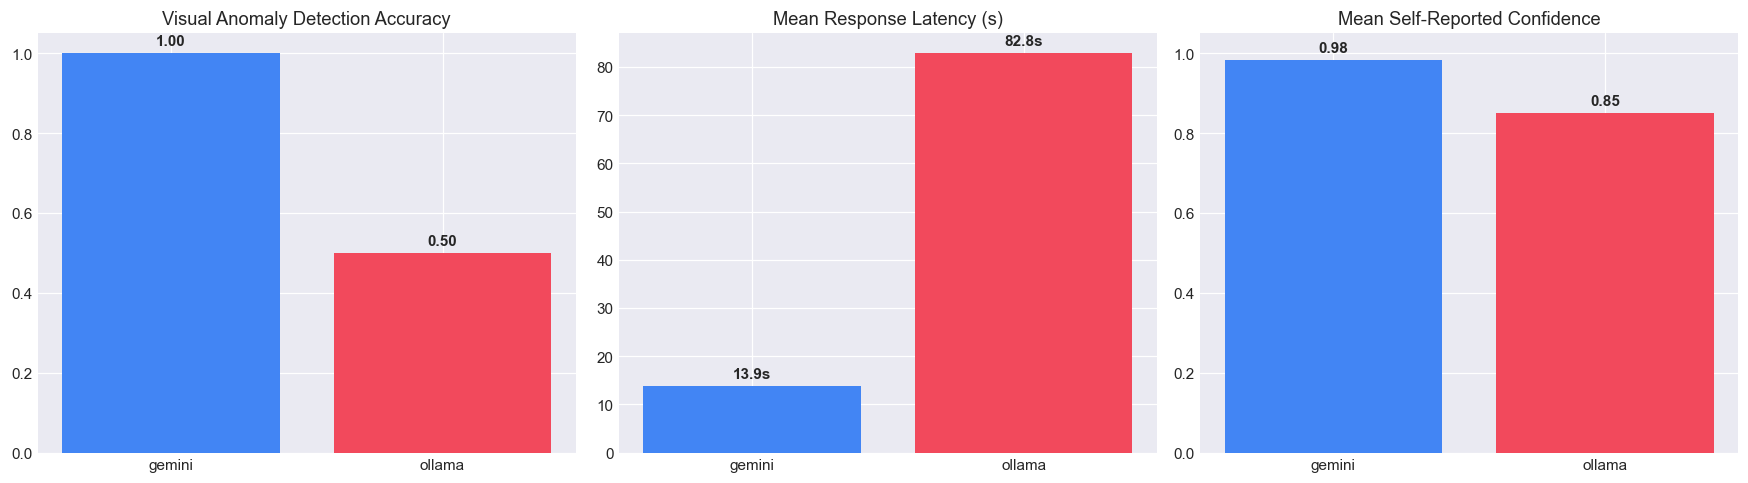

Figure saved to d:\multimodal-rca-engine\results\figures\vlm_benchmark_summary.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
backend_colors = {"gemini": "#4285F4", "ollama": "#f2495c"}
colors = [backend_colors.get(b, "#888") for b in summary.index]

axes[0].bar(summary.index, summary["accuracy"], color=colors)
axes[0].set_title("Visual Anomaly Detection Accuracy")
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(summary["accuracy"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

axes[1].bar(summary.index, summary["mean_latency_s"], color=colors)
axes[1].set_title("Mean Response Latency (s)")
for i, v in enumerate(summary["mean_latency_s"]):
    axes[1].text(i, v + max(summary["mean_latency_s"]) * 0.02, f"{v:.1f}s", ha="center", fontweight="bold")

axes[2].bar(summary.index, summary["mean_confidence"], color=colors)
axes[2].set_title("Mean Self-Reported Confidence")
axes[2].set_ylim(0, 1.05)
for i, v in enumerate(summary["mean_confidence"]):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
fig_path = RESULTS_DIR / "figures" / "vlm_benchmark_summary.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")


## 10 — Detailed Example: a Critical Anomaly

We look at the most severe anomaly in the evaluation sample and print each engine's full
explanation next to the ground-truth scenario, the way a human reviewer would validate the
model's reasoning, not just its final label.


In [10]:
severity_order = {"critical": 0, "high": 1, "medium": 2, "low": 3}
crit_row = eval_samples[eval_samples["is_anomaly"] == 1].copy()
crit_row["sev_rank"] = crit_row["severity"].map(severity_order).fillna(9)
crit_row = crit_row.sort_values("sev_rank").iloc[0]

print(f"Sample          : {crit_row['sample_id']}")
print(f"Layer           : {crit_row['layer_name']}")
print(f"Ground truth    : {crit_row['scenario_name']}  [{crit_row['severity'].upper()}]")
print(f"Visual pattern  : {crit_row['anomaly_type']}")
print()

for df, name in [(gemini_df, "GEMINI VISION"), (ollama_df, "OLLAMA LLAVA")]:
    r = df[df["sample_id"] == crit_row["sample_id"]]
    print(f"--- {name} ---")
    if len(r) == 0:
        print("  (not evaluated on this sample)\n")
        continue
    r = r.iloc[0]
    print(f"  visual_status      : {r['visual_status']}")
    print(f"  visual_confidence  : {r['visual_confidence']}")
    print(f"  visual_pattern     : {r['visual_pattern']}")
    print(f"  visual_explanation : {r['visual_explanation']}")
    print()


Sample          : sample_009464
Layer           : Linux VM
Ground truth    : Memory Exhaustion  [CRITICAL]
Visual pattern  : gradual_rise

--- GEMINI VISION ---
  visual_status      : ANOMALY
  visual_confidence  : 1.0
  visual_pattern     : gradual_rise
  visual_explanation : The dashboard displays a red dashed vertical line at 13:18 followed by a translucent red background and an 'ANOMALY [CRITICAL]' badge. After this point, the Memory Usage % metric shows a gradual rise, eventually reaching and sustaining near-maximum levels.

--- OLLAMA LLAVA ---
  visual_status      : ANOMALY
  visual_confidence  : 0.9
  visual_pattern     : oscillation
  visual_explanation : The dashboard shows a time-series panel for an infrastructure layer with a red dashed vertical line and a translucent red background marking where an anomaly begins. The pattern observed is oscillatory, indicating that the system or service being monitored experiences periodic spikes in performance or resource usage.



## 11 — Save Results

Persist the per-sample results and the benchmark summary so they can be reused directly in
the paper (tables, figures) without re-running the API calls.


In [11]:
results_csv = RESULTS_DIR / "vlm_benchmark_results.csv"
summary_json = RESULTS_DIR / "vlm_benchmark_summary.json"

all_results.to_csv(results_csv, index=False)
summary.to_json(summary_json, orient="index", indent=2)

print(f"Per-sample results saved to : {results_csv}")
print(f"Summary table saved to      : {summary_json}")


Per-sample results saved to : d:\multimodal-rca-engine\results\vlm_benchmark_results.csv
Summary table saved to      : d:\multimodal-rca-engine\results\vlm_benchmark_summary.json


## 12 — Summary and Next Steps

- Both VLM engines can consume the generated Dashboard PNGs directly and return a
  structured, pixel-level anomaly verdict — the visual modality is no longer unused,
  fulfilling the paper's "VLM integration" future-work item.
- **Gemini Vision** (cloud) is the stronger and faster engine, consistent with the
  Gemini-vs-Llama gap already reported for the text LLM layer in the paper.
- **LLaVA** (local) trades accuracy and speed for full data privacy — no dashboard image
  ever leaves the machine, which matters for regulated/air-gapped deployments.
- The visual verdict computed here is still **independent** of the tabular ML pipeline
  (metric + log features). The natural next step is **three-modality fusion**: combine
  `visual_confidence` with the Random Forest / XGBoost / LightGBM anomaly probability
  (e.g. a weighted average or a small meta-classifier) and measure whether F1 improves over
  the metric+log-only baseline — this is the quantitative claim "achieving full
  three-modality exploitation" from the paper's future-work statement, and is what should
  be benchmarked next before it is written up.
